# Historical Tail Event Analysis

Análisis histórico de eventos extremos de cola. El objetivo es evaluar el comportamiento de las estrategias en episodios adversos observados, sin construir escenarios hipotéticos, simulados ni shocks artificiales.

Se analizan dos bloques:

1. Peor 5% de días out-of-sample definidos sobre el retorno del mercado.
2. Episodio histórico definido ex ante: invasión rusa de Ucrania, con fecha central 2022-02-24 y ventana de 20 sesiones bursátiles antes y después.


In [1]:
# Cell 1. Imports y rutas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed"
TABLES_PATH = PROJECT_ROOT / "tables" / "chapter6"
FIGURES_PATH = PROJECT_ROOT / "figures" / "chapter6"
MAPPING_PATH = PROJECT_ROOT / "tables" / "chapter4"

TABLES_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

EVENT_NAME = "Russian invasion of Ukraine"
EVENT_DATE = pd.Timestamp("2022-02-24")
WINDOW_OBSERVATIONS = 20
TAIL_PERCENTILE = 0.05


In [2]:
# Cell 2. Carga de backtests MAIN y ROBUST

BACKTEST_FILES = {
    "MAIN": {
        "regime": DATA_PATH / "backtest_oos_results.csv",
        "ml": DATA_PATH / "backtest_ml_results.csv",
        "mapping": MAPPING_PATH / "regime_exposure_mapping.csv",
    },
    "ROBUST": {
        "regime": DATA_PATH / "backtest_oos_results_robust.csv",
        "ml": DATA_PATH / "backtest_ml_results_robust.csv",
        "mapping": MAPPING_PATH / "regime_exposure_mapping_robust.csv",
    },
}

raw_backtests = {}

for sample, paths in BACKTEST_FILES.items():
    regime_bt = pd.read_csv(paths["regime"], parse_dates=["date"]).sort_values("date")
    ml_bt = pd.read_csv(paths["ml"], parse_dates=["date"]).sort_values("date")

    raw_backtests[sample] = {
        "regime": regime_bt.reset_index(drop=True),
        "ml": ml_bt.reset_index(drop=True),
    }

    print(sample)
    print("Regime-based:", regime_bt.shape, regime_bt["date"].min(), "->", regime_bt["date"].max())
    print("ML:", ml_bt.shape, ml_bt["date"].min(), "->", ml_bt["date"].max())


MAIN
Regime-based: (1356, 20) 2021-01-05 00:00:00 -> 2026-04-23 00:00:00
ML: (1355, 22) 2021-01-05 00:00:00 -> 2026-04-22 00:00:00
ROBUST
Regime-based: (1613, 20) 2020-01-03 00:00:00 -> 2026-04-23 00:00:00
ML: (1612, 22) 2020-01-03 00:00:00 -> 2026-04-22 00:00:00


In [3]:
# Cell 3. Carga de mappings e identificación de High Risk

high_risk_regimes = {}
regime_mappings = {}

for sample, paths in BACKTEST_FILES.items():
    mapping = pd.read_csv(paths["mapping"])
    required_cols = {"regime", "economic_label", "risk_order", "target_exposure"}
    missing_cols = required_cols - set(mapping.columns)
    if missing_cols:
        raise ValueError(f"{sample}: faltan columnas en mapping: {sorted(missing_cols)}")

    high_rows = mapping[mapping["economic_label"].eq("high_risk")]
    if len(high_rows) != 1:
        raise ValueError(f"{sample}: debe existir exactamente un régimen high_risk")

    high_risk_regime = int(high_rows["regime"].iloc[0])
    high_risk_regimes[sample] = high_risk_regime
    regime_mappings[sample] = mapping.copy()

    print(sample, "high_risk_regime:", high_risk_regime)
    display(mapping[["regime", "economic_label", "risk_order", "target_exposure"]])


MAIN high_risk_regime: 1


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.000000
1,2,medium_risk,2,0.590556
2,1,high_risk,3,0.355552


ROBUST high_risk_regime: 2


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.000000
1,1,medium_risk,2,0.600708
2,2,high_risk,3,0.388559


In [4]:
# Cell 4. Construcción de datasets comunes por fecha

STRATEGY_CONFIG = {
    "Buy & Hold": {
        "return_col": "benchmark_return",
        "exposure_col": None,
        "regime_source": "regime",
    },
    "Regime-based": {
        "return_col": "strategy_return",
        "exposure_col": "strategy_exposure",
        "regime_source": "regime",
    },
    "ML Hard Classification": {
        "return_col": "ml_hard_return",
        "exposure_col": "strategy_exposure_ml_hard",
        "regime_source": "regime_pred",
    },
    "ML Probability-Weighted": {
        "return_col": "ml_proba_return",
        "exposure_col": "strategy_exposure_ml_proba",
        "regime_source": "regime_pred",
    },
}

common_backtests = {}

for sample, data in raw_backtests.items():
    regime_cols = [
        "date",
        "ret_1d",
        "benchmark_return",
        "strategy_return",
        "benchmark_cum",
        "strategy_cum",
        "regime",
        "target_exposure",
        "strategy_exposure",
        "p_regime_0",
        "p_regime_1",
        "p_regime_2",
    ]
    ml_cols = [
        "date",
        "ml_hard_return",
        "ml_proba_return",
        "ml_hard_cum",
        "ml_proba_cum",
        "benchmark_drawdown",
        "ml_hard_drawdown",
        "ml_proba_drawdown",
        "regime_pred",
        "target_exposure_ml_hard",
        "target_exposure_ml_proba",
        "strategy_exposure_ml_hard",
        "strategy_exposure_ml_proba",
        "proba_0",
        "proba_1",
        "proba_2",
    ]

    regime_bt = data["regime"][regime_cols].copy()
    ml_bt = data["ml"][ml_cols].copy()

    df_common = regime_bt.merge(ml_bt, on="date", how="inner")
    df_common = df_common.sort_values("date").reset_index(drop=True)

    if df_common.empty:
        raise ValueError(f"{sample}: dataset común vacío")
    if df_common["date"].duplicated().any():
        raise ValueError(f"{sample}: fechas duplicadas tras merge")
    if not df_common["date"].is_monotonic_increasing:
        raise ValueError(f"{sample}: fechas no ordenadas")

    required_returns = [cfg["return_col"] for cfg in STRATEGY_CONFIG.values()]
    if df_common[required_returns].isna().any().any():
        raise ValueError(f"{sample}: NaN en retornos principales")

    common_backtests[sample] = df_common

    print(sample, df_common.shape, df_common["date"].min(), "->", df_common["date"].max())


MAIN (1355, 27) 2021-01-05 00:00:00 -> 2026-04-22 00:00:00
ROBUST (1612, 27) 2020-01-03 00:00:00 -> 2026-04-22 00:00:00


In [5]:
# Cell 5. Funciones auxiliares

def cumulative_return_from_log_returns(returns):
    returns = returns.dropna()
    return np.exp(returns.sum()) - 1


def drawdown_from_log_returns(returns):
    returns = returns.dropna()
    cumulative = np.exp(returns.cumsum())
    return cumulative / cumulative.cummax() - 1


def summarize_return_window(returns):
    returns = returns.dropna()
    if returns.empty:
        raise ValueError("La serie de retornos está vacía")

    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    drawdown = drawdown_from_log_returns(returns)

    return {
        "cumulative_return_window": cumulative_return_from_log_returns(returns),
        "mean_daily_return": returns.mean(),
        "daily_volatility": returns.std(),
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "max_drawdown_window": drawdown.min(),
    }


def high_risk_probability_col(sample, prefix):
    col = f"{prefix}_{high_risk_regimes[sample]}"
    return col


def validate_probability_column(df, col):
    if col not in df.columns:
        return False
    return not df[col].isna().all()


## Peor 5% de días OOS

Los eventos de cola se definen a partir del peor 5% de retornos diarios del mercado en el periodo out-of-sample común entre el backtest por regímenes y el backtest ML.


In [6]:
# Cell 6. Análisis del peor 5% de días OOS

tail_results = []
tail_event_datasets = {}

for sample, df_common in common_backtests.items():
    threshold = df_common["ret_1d"].quantile(TAIL_PERCENTILE)
    df = df_common.copy()
    df["tail_event"] = df["ret_1d"] <= threshold
    df_tail_events = df[df["tail_event"]].copy().sort_values("date").reset_index(drop=True)

    tail_share = len(df_tail_events) / len(df)
    if not np.isclose(tail_share, TAIL_PERCENTILE, atol=0.01):
        raise ValueError(f"{sample}: la cola no representa aproximadamente el 5%")

    tail_event_datasets[sample] = df_tail_events

    for strategy, cfg in STRATEGY_CONFIG.items():
        returns = df_tail_events[cfg["return_col"]].dropna()
        var_95 = returns.quantile(0.05)
        cvar_95 = returns[returns <= var_95].mean()
        drawdown = drawdown_from_log_returns(returns)

        tail_results.append(
            {
                "sample": sample,
                "analysis": "Worst 5% OOS market days",
                "threshold": threshold,
                "tail_days": len(df_tail_events),
                "strategy": strategy,
                "total_return_tail": cumulative_return_from_log_returns(returns),
                "mean_return_tail": returns.mean(),
                "volatility_tail": returns.std(),
                "VaR_95_tail": var_95,
                "CVaR_95_tail": cvar_95,
                "worst_day": returns.min(),
                "max_drawdown_tail": drawdown.min(),
            }
        )

    print(sample)
    print("Threshold:", round(threshold, 6))
    print("Tail days:", len(df_tail_events), "of", len(df), "share", round(tail_share, 4))
    print("Tail event range:", df_tail_events["date"].min(), "->", df_tail_events["date"].max())

tail_event_analysis = pd.DataFrame(tail_results)
display(tail_event_analysis)


MAIN
Threshold: -0.015877
Tail days: 68 of 1355 share 0.0502
Tail event range: 2021-01-15 00:00:00 -> 2026-03-19 00:00:00
ROBUST
Threshold: -0.017651
Tail days: 81 of 1612 share 0.0502
Tail event range: 2020-01-27 00:00:00 -> 2026-03-19 00:00:00


,sample,analysis,threshold,tail_days,strategy,total_return_tail,mean_return_tail,volatility_tail,VaR_95_tail,CVaR_95_tail,worst_day,max_drawdown_tail
0,MAIN,Worst 5% OOS market days,-0.015877,68,Buy & Hold,-0.801410,-0.023772,0.009729,-0.046009,-0.052559,-0.060081,-0.797991
1,MAIN,Worst 5% OOS market days,-0.015877,68,Regime-based,-0.702916,-0.017849,0.007616,-0.031355,-0.038609,-0.050836,-0.697801
2,MAIN,Worst 5% OOS market days,-0.015877,68,ML Hard Classification,-0.705540,-0.017980,0.007739,-0.031904,-0.038609,-0.050836,-0.702557
3,MAIN,Worst 5% OOS market days,-0.015877,68,ML Probability-Weighted,-0.709442,-0.018176,0.007628,-0.030010,-0.040119,-0.050181,-0.706278
4,ROBUST,Worst 5% OOS market days,-0.017651,81,Buy & Hold,-0.916544,-0.030660,0.018550,-0.052574,-0.085843,-0.151512,-0.914801
5,ROBUST,Worst 5% OOS market days,-0.017651,81,Regime-based,-0.786373,-0.019056,0.010315,-0.035753,-0.049425,-0.060081,-0.781909
6,ROBUST,Worst 5% OOS market days,-0.017651,81,ML Hard Classification,-0.789122,-0.019216,0.009330,-0.035753,-0.044627,-0.058871,-0.784715
7,ROBUST,Worst 5% OOS market days,-0.017651,81,ML Probability-Weighted,-0.794375,-0.019527,0.009441,-0.037893,-0.047172,-0.060416,-0.790100


## Episodio histórico ex ante: invasión rusa de Ucrania

La ventana se define por observaciones bursátiles: 20 sesiones antes, la fecha central 2022-02-24 y 20 sesiones después.


In [7]:
# Cell 7. Selección de ventana Ucrania 20/20

ukraine_windows = {}

for sample, df_common in common_backtests.items():
    event_matches = df_common.index[df_common["date"].eq(EVENT_DATE)].tolist()
    if len(event_matches) != 1:
        raise ValueError(f"{sample}: la fecha del evento no aparece exactamente una vez")

    event_idx = event_matches[0]
    start_idx = event_idx - WINDOW_OBSERVATIONS
    end_idx = event_idx + WINDOW_OBSERVATIONS

    if start_idx < 0 or end_idx >= len(df_common):
        raise ValueError(f"{sample}: observaciones insuficientes para ventana 20/20")

    window = df_common.iloc[start_idx : end_idx + 1].copy().reset_index(drop=True)

    if len(window) != 2 * WINDOW_OBSERVATIONS + 1:
        raise ValueError(f"{sample}: la ventana no tiene 41 observaciones")
    if EVENT_DATE not in set(window["date"]):
        raise ValueError(f"{sample}: la fecha central no está incluida en la ventana")

    ukraine_windows[sample] = window

    print(sample)
    print("Window rows:", len(window))
    print("Window range:", window["date"].min(), "->", window["date"].max())
    print("Event date present:", EVENT_DATE in set(window["date"]))


MAIN
Window rows: 41
Window range: 2022-01-27 00:00:00 -> 2022-03-24 00:00:00
Event date present: True
ROBUST
Window rows: 41
Window range: 2022-01-27 00:00:00 -> 2022-03-24 00:00:00
Event date present: True


In [8]:
# Cell 8. Métricas de ventana Ucrania

ukraine_results = []

for sample, window in ukraine_windows.items():
    high_regime = high_risk_regimes[sample]
    regime_high_proba_col = high_risk_probability_col(sample, "p_regime")
    ml_high_proba_col = high_risk_probability_col(sample, "proba")

    for strategy, cfg in STRATEGY_CONFIG.items():
        returns = window[cfg["return_col"]].dropna()
        row = {
            "sample": sample,
            "event": EVENT_NAME,
            "window_start": window["date"].min(),
            "event_date": EVENT_DATE,
            "window_end": window["date"].max(),
            "window_rows": len(window),
            "strategy": strategy,
            **summarize_return_window(returns),
        }

        exposure_col = cfg["exposure_col"]
        if exposure_col is None:
            row["average_exposure"] = 1.0
            row["min_exposure"] = 1.0
            row["max_exposure"] = 1.0
        else:
            exposure = window[exposure_col].dropna()
            row["average_exposure"] = exposure.mean()
            row["min_exposure"] = exposure.min()
            row["max_exposure"] = exposure.max()

        if cfg["regime_source"] == "regime":
            probability_col = regime_high_proba_col
            regime_col = "regime"
        else:
            probability_col = ml_high_proba_col
            regime_col = "regime_pred"

        if validate_probability_column(window, probability_col):
            row["average_high_risk_probability"] = window[probability_col].mean()
        else:
            row["average_high_risk_probability"] = np.nan

        if regime_col in window.columns:
            row["share_high_risk_days"] = window[regime_col].astype(int).eq(high_regime).mean()
        else:
            row["share_high_risk_days"] = np.nan

        ukraine_results.append(row)

ukraine_event_window_analysis = pd.DataFrame(ukraine_results)
display(ukraine_event_window_analysis)


,sample,event,window_start,event_date,window_end,window_rows,strategy,cumulative_return_window,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown_window,average_exposure,min_exposure,max_exposure,average_high_risk_probability,share_high_risk_days
0,MAIN,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,Buy & Hold,-0.036554,-0.000908,0.017788,-0.034922,-0.036591,-0.139722,1.000000,1.000000,1.000000,0.266255,0.268293
1,MAIN,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,Regime-based,-0.036554,-0.000908,0.009064,-0.017151,-0.020056,-0.078402,0.527506,0.355552,0.590556,0.266255,0.268293
2,MAIN,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,ML Hard Classification,-0.033056,-0.000820,0.009152,-0.017151,-0.020056,-0.074911,0.527506,0.355552,0.590556,0.254980,0.268293
3,MAIN,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,ML Probability-Weighted,-0.032594,-0.000808,0.009647,-0.017941,-0.020177,-0.081430,0.565412,0.357444,0.751445,0.254980,0.268293
4,ROBUST,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,Buy & Hold,-0.036554,-0.000908,0.017788,-0.034922,-0.036591,-0.139722,1.000000,1.000000,1.000000,0.276174,0.268293
5,ROBUST,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,Regime-based,-0.035489,-0.000881,0.009359,-0.017446,-0.020400,-0.080456,0.543790,0.388559,0.600708,0.276174,0.268293
6,ROBUST,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,ML Hard Classification,-0.031634,-0.000784,0.009437,-0.017446,-0.020400,-0.077312,0.538616,0.388559,0.600708,0.287771,0.292683
7,ROBUST,Russian invasion of Ukraine,2022-01-27,2022-02-24,2022-03-24,41,ML Probability-Weighted,-0.032587,-0.000808,0.009833,-0.017997,-0.020527,-0.082535,0.570963,0.389214,0.783453,0.287771,0.292683


In [9]:
# Cell 9. Exportación de tablas

tail_output_csv = TABLES_PATH / "tail_event_analysis.csv"
tail_output_tex = TABLES_PATH / "tail_event_analysis.tex"
ukraine_output_csv = TABLES_PATH / "ukraine_event_window_analysis.csv"
ukraine_output_tex = TABLES_PATH / "ukraine_event_window_analysis.tex"

tail_event_analysis.to_csv(tail_output_csv, index=False)
tail_event_analysis.to_latex(tail_output_tex, index=False, float_format="%.6f")

ukraine_event_window_analysis.to_csv(ukraine_output_csv, index=False)
ukraine_event_window_analysis.to_latex(ukraine_output_tex, index=False, float_format="%.6f")

# Backward-compatible copy for legacy Notebook 06 references. The academic output is tail_event_analysis.csv.
legacy_output_csv = TABLES_PATH / "stress_test_tail_events.csv"
legacy_cols = [
    "strategy",
    "tail_days",
    "total_return_tail",
    "mean_return_tail",
    "volatility_tail",
    "VaR_95_tail",
    "CVaR_95_tail",
    "worst_day",
    "max_drawdown_tail",
]
tail_event_analysis[tail_event_analysis["sample"].eq("MAIN")][legacy_cols].rename(
    columns={"tail_days": "n_days"}
).to_csv(legacy_output_csv, index=False)

print("Exported:", tail_output_csv)
print("Exported:", tail_output_tex)
print("Exported:", ukraine_output_csv)
print("Exported:", ukraine_output_tex)
print("Legacy compatibility copy:", legacy_output_csv)


Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/tail_event_analysis.csv
Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/tail_event_analysis.tex
Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ukraine_event_window_analysis.csv
Exported: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ukraine_event_window_analysis.tex
Legacy compatibility copy: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/stress_test_tail_events.csv


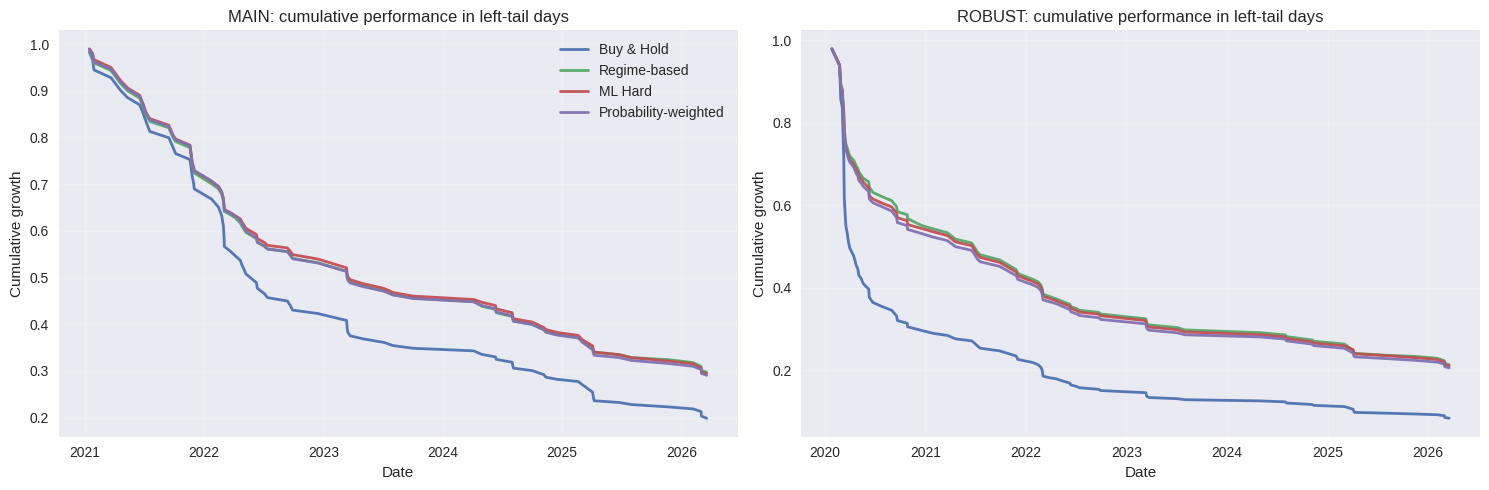

Exported figure: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/tail_event_cumulative_returns.png


In [10]:
# Cell 10. Figura: acumulados durante días de cola históricos

plot_labels = {
    "Buy & Hold": "Buy & Hold",
    "Regime-based": "Regime-based",
    "ML Hard Classification": "ML Hard",
    "ML Probability-Weighted": "Probability-weighted",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, sample in zip(axes, ["MAIN", "ROBUST"]):
    df_tail_events = tail_event_datasets[sample]
    for strategy, cfg in STRATEGY_CONFIG.items():
        cumulative = np.exp(df_tail_events[cfg["return_col"]].cumsum())
        ax.plot(
            df_tail_events["date"],
            cumulative,
            label=plot_labels[strategy],
            linewidth=2,
            alpha=0.95,
        )

    ax.set_title(f"{sample}: cumulative performance in left-tail days")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative growth")
    ax.grid(True, alpha=0.2)

axes[0].legend(frameon=False)
plt.tight_layout()

fig_path = FIGURES_PATH / "tail_event_cumulative_returns.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Exported figure:", fig_path)


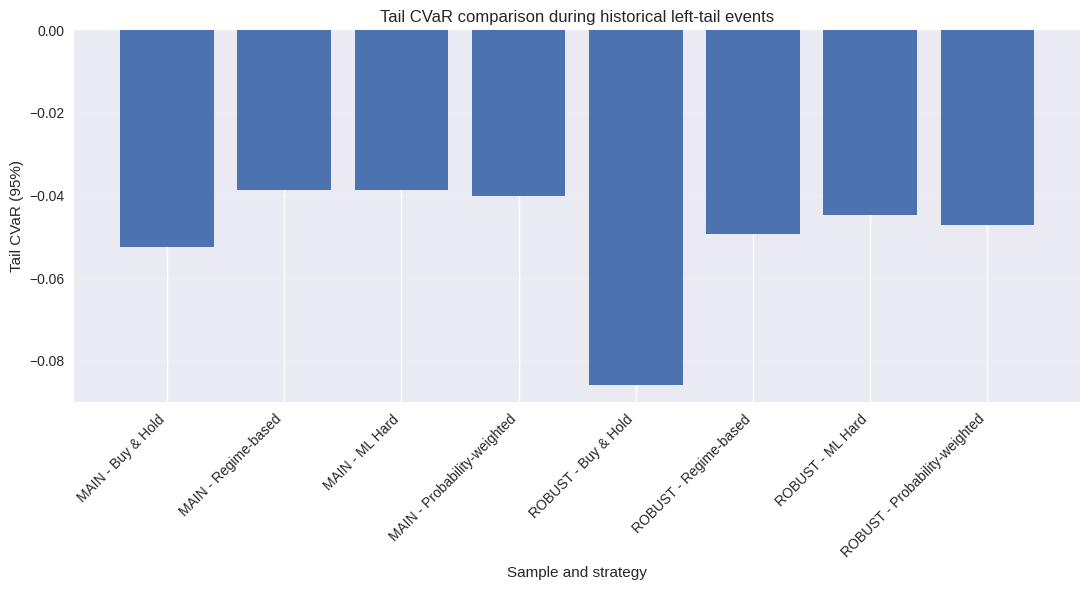

Exported figure: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/tail_event_bar_comparison.png


In [11]:
# Cell 11. Figura: comparación de CVaR en cola

fig, ax = plt.subplots(figsize=(11, 6))

bar_data = tail_event_analysis.copy()
bar_data["strategy_label"] = bar_data["strategy"].map(plot_labels)
bar_data["sample_strategy"] = bar_data["sample"] + " - " + bar_data["strategy_label"]

ax.bar(bar_data["sample_strategy"], bar_data["CVaR_95_tail"])
ax.set_title("Tail CVaR comparison during historical left-tail events")
ax.set_xlabel("Sample and strategy")
ax.set_ylabel("Tail CVaR (95%)")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = FIGURES_PATH / "tail_event_bar_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Exported figure:", fig_path)


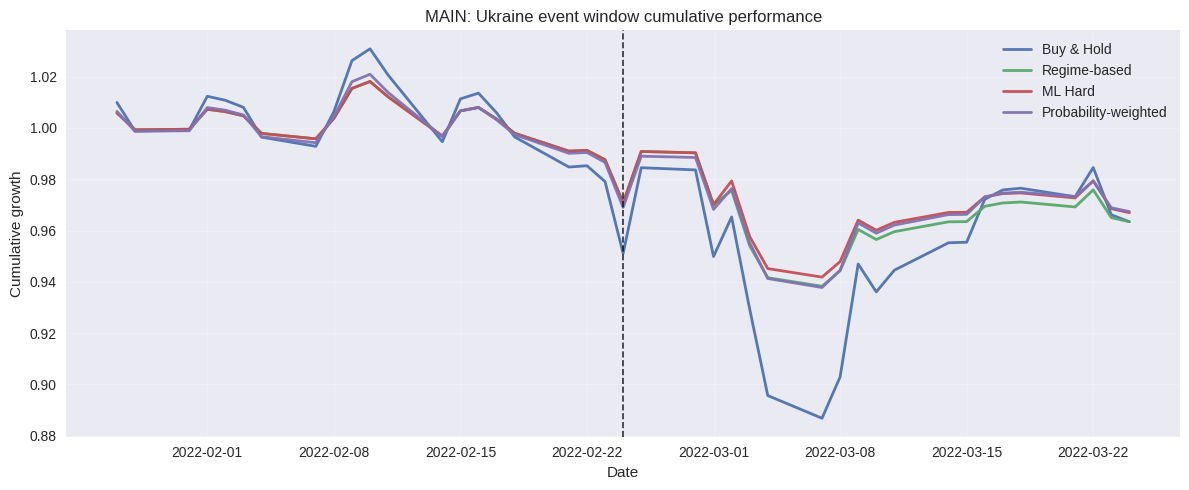

Exported figure: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ukraine_event_cumulative_returns_main.png


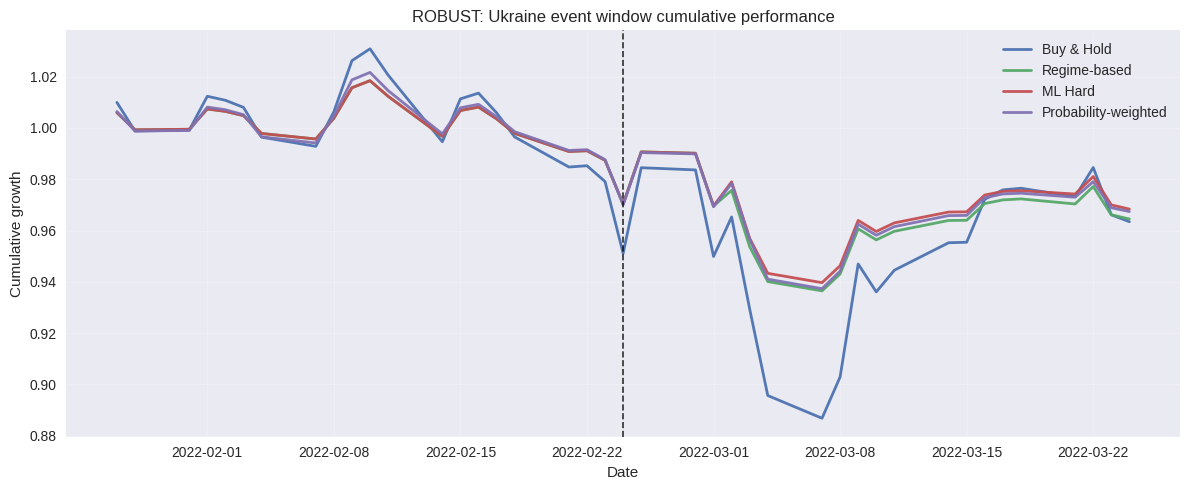

Exported figure: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/figures/chapter6/ukraine_event_cumulative_returns_robust.png


In [12]:
# Cell 12. Figuras: acumulados durante la ventana Ucrania

for sample, window in ukraine_windows.items():
    plt.figure(figsize=(12, 5))

    for strategy, cfg in STRATEGY_CONFIG.items():
        cumulative = np.exp(window[cfg["return_col"]].cumsum())
        plt.plot(
            window["date"],
            cumulative,
            label=plot_labels[strategy],
            linewidth=2,
            alpha=0.95,
        )

    plt.axvline(EVENT_DATE, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    plt.title(f"{sample}: Ukraine event window cumulative performance")
    plt.xlabel("Date")
    plt.ylabel("Cumulative growth")
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()

    fig_path = FIGURES_PATH / f"ukraine_event_cumulative_returns_{sample.lower()}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Exported figure:", fig_path)


In [13]:
# Cell 13. Validaciones finales

required_outputs = [
    tail_output_csv,
    tail_output_tex,
    ukraine_output_csv,
    ukraine_output_tex,
    FIGURES_PATH / "tail_event_cumulative_returns.png",
    FIGURES_PATH / "tail_event_bar_comparison.png",
    FIGURES_PATH / "ukraine_event_cumulative_returns_main.png",
    FIGURES_PATH / "ukraine_event_cumulative_returns_robust.png",
]

missing_outputs = [path for path in required_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Faltan outputs esperados: {missing_outputs}")

for sample, window in ukraine_windows.items():
    if len(window) != 41:
        raise ValueError(f"{sample}: la ventana Ucrania no tiene 41 observaciones")
    if EVENT_DATE not in set(window["date"]):
        raise ValueError(f"{sample}: falta la fecha central Ucrania")

print("Historical Tail Event Analysis completed.")
print("Samples:", list(common_backtests.keys()))
print("High Risk regimes:", high_risk_regimes)
print("Tail output:", tail_output_csv)
print("Ukraine output:", ukraine_output_csv)


Historical Tail Event Analysis completed.
Samples: ['MAIN', 'ROBUST']
High Risk regimes: {'MAIN': 1, 'ROBUST': 2}
Tail output: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/tail_event_analysis.csv
Ukraine output: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter6/ukraine_event_window_analysis.csv
